In [203]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [204]:
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [205]:
(df.isna().sum() / len(df)) * 100


Date             0.000000
Time            42.122248
Location         0.379651
Operator         0.341686
Flight #        79.707669
Route           32.403189
Type             0.512528
Registration     6.359150
cn/In           23.310554
Aboard           0.417616
Fatalities       0.227790
Ground           0.417616
Summary          7.403189
dtype: float64

In [206]:
df_revised = df[['Date','Location','Operator','Route','Type','Registration','Fatalities','Summary']].copy()

df_revised = df_revised.rename(columns={
    'Date':'Crash_Date',
    'Location':'Crash_Location',
    'Operator':'Operation_carried_by',
    'Route':'Flight_Route',
    'Type':'Flight_Type',
    'Registration':'Flight_Registration_Number',
    'Fatalities':'Fatalities_in_Crash',
    'Summary':'Crash_Description'
    
})


In [207]:
df_revised.head()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description
0,09/17/1908,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,NaN,1.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,NaN,5.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,"Victoria, British Columbia, Canada",Private,NaN,Curtiss seaplane,NaN,1.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,Over the North Sea,Military - German Navy,NaN,Zeppelin L-1 (airship),NaN,14.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,"Near Johannisthal, Germany",Military - German Navy,NaN,Zeppelin L-2 (airship),NaN,30.0,Hydrogen gas which was being vented was sucked...


In [208]:
(df_revised.isna().sum() / len(df_revised)) * 100

Crash_Date                     0.000000
Crash_Location                 0.379651
Operation_carried_by           0.341686
Flight_Route                  32.403189
Flight_Type                    0.512528
Flight_Registration_Number     6.359150
Fatalities_in_Crash            0.227790
Crash_Description              7.403189
dtype: float64

In [128]:
# you can willingly see that fliht route has highest null values so let me first handle this

# HANDLING MISSING VALUES

In [209]:
df_revised['Flight_Route'] = df_revised['Flight_Route'].fillna('Was Missing')

In [210]:
df_revised['Flight_Registration_Number'] = df_revised['Flight_Registration_Number'].fillna('Not Available')

In [211]:
df_revised = df_revised.dropna()

In [212]:
(df_revised.isna().sum() / len(df_revised)) * 100

Crash_Date                    0.0
Crash_Location                0.0
Operation_carried_by          0.0
Flight_Route                  0.0
Flight_Type                   0.0
Flight_Registration_Number    0.0
Fatalities_in_Crash           0.0
Crash_Description             0.0
dtype: float64

In [213]:
df_revised.dtypes

Crash_Date                     object
Crash_Location                 object
Operation_carried_by           object
Flight_Route                   object
Flight_Type                    object
Flight_Registration_Number     object
Fatalities_in_Crash           float64
Crash_Description              object
dtype: object

In [214]:
df_revised['Crash_Date'] = pd.to_datetime(df_revised['Crash_Date'], errors='coerce')

In [215]:
df_revised.dtypes

Crash_Date                    datetime64[ns]
Crash_Location                        object
Operation_carried_by                  object
Flight_Route                          object
Flight_Type                           object
Flight_Registration_Number            object
Fatalities_in_Crash                  float64
Crash_Description                     object
dtype: object

In [216]:
df_revised.head()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description
0,1908-09-17,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,Not Available,1.0,"During a demonstration flight, a U.S. Army fly..."
1,1912-07-12,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,Not Available,5.0,First U.S. dirigible Akron exploded just offsh...
2,1913-08-06,"Victoria, British Columbia, Canada",Private,Was Missing,Curtiss seaplane,Not Available,1.0,The first fatal airplane accident in Canada oc...
3,1913-09-09,Over the North Sea,Military - German Navy,Was Missing,Zeppelin L-1 (airship),Not Available,14.0,The airship flew into a thunderstorm and encou...
4,1913-10-17,"Near Johannisthal, Germany",Military - German Navy,Was Missing,Zeppelin L-2 (airship),Not Available,30.0,Hydrogen gas which was being vented was sucked...


In [217]:
df_revised.drop_duplicates()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description
0,1908-09-17,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,Not Available,1.0,"During a demonstration flight, a U.S. Army fly..."
1,1912-07-12,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,Not Available,5.0,First U.S. dirigible Akron exploded just offsh...
2,1913-08-06,"Victoria, British Columbia, Canada",Private,Was Missing,Curtiss seaplane,Not Available,1.0,The first fatal airplane accident in Canada oc...
3,1913-09-09,Over the North Sea,Military - German Navy,Was Missing,Zeppelin L-1 (airship),Not Available,14.0,The airship flew into a thunderstorm and encou...
4,1913-10-17,"Near Johannisthal, Germany",Military - German Navy,Was Missing,Zeppelin L-2 (airship),Not Available,30.0,Hydrogen gas which was being vented was sucked...
...,...,...,...,...,...,...,...,...
5263,2009-05-20,"Near Madiun, Indonesia",Military - Indonesian Air Force,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,98.0,"While on approach, the military transport cras..."
5264,2009-05-26,"Near Isiro, DemocratiRepubliCongo",Service Air,Goma - Isiro,Antonov An-26,9Q-CSA,4.0,The cargo plane crashed while on approach to I...
5265,2009-06-01,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,228.0,The Airbus went missing over the AtlantiOcean ...
5266,2009-06-07,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,1.0,The air ambulance crashed into hills while att...


In [218]:
df_revised.shape

(4831, 8)

In [219]:
df.describe()

,Aboard,Fatalities,Ground
count,5246.000000,5256.000000,5246.000000
mean,27.554518,20.068303,1.608845
std,43.076711,33.199952,53.987827
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,13.000000,9.000000,0.000000
75%,30.000000,23.000000,0.000000
max,644.000000,583.000000,2750.000000


In [140]:
# in conclusion we can seee
#  Most flights had small passenger counts, with 50% having 13 or fewer people aboard.

#  Median fatalities per crash is just 9, showing many crashes were not totally fatal.

#  Ground fatalities were 0 in most cases, meaning crashes usually didn't impact people on land.

#  Severe outliers exist, like one crash causing 2750 ground deaths, skewing the average.

#  A few high-fatality crashes (up to 583 deaths) significantly raise the mean compared to the median.

In [141]:
# df.info

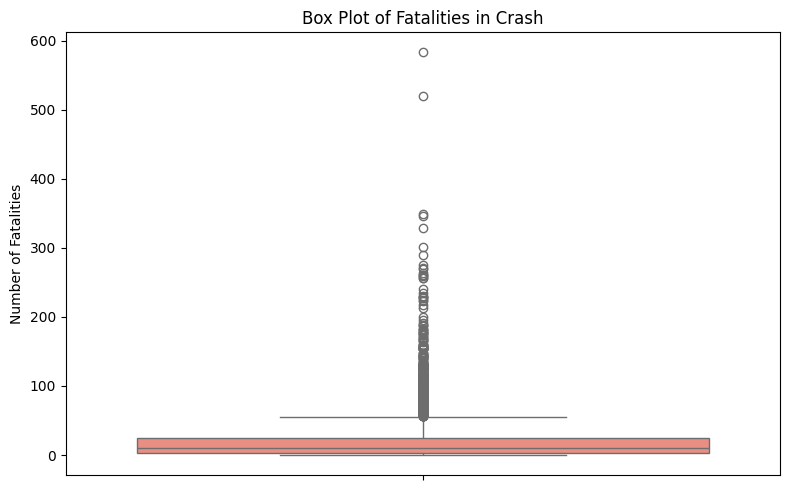

In [220]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_revised, y='Fatalities_in_Crash', color='salmon')
plt.title('Box Plot of Fatalities in Crash')
plt.ylabel('Number of Fatalities')
plt.tight_layout()
plt.show()

# jjust ignore this as it is needed

In [221]:
df_revised.head()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description
0,1908-09-17,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,Not Available,1.0,"During a demonstration flight, a U.S. Army fly..."
1,1912-07-12,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,Not Available,5.0,First U.S. dirigible Akron exploded just offsh...
2,1913-08-06,"Victoria, British Columbia, Canada",Private,Was Missing,Curtiss seaplane,Not Available,1.0,The first fatal airplane accident in Canada oc...
3,1913-09-09,Over the North Sea,Military - German Navy,Was Missing,Zeppelin L-1 (airship),Not Available,14.0,The airship flew into a thunderstorm and encou...
4,1913-10-17,"Near Johannisthal, Germany",Military - German Navy,Was Missing,Zeppelin L-2 (airship),Not Available,30.0,Hydrogen gas which was being vented was sucked...


In [143]:
# Now we perform Feature Engineering

In [144]:
# extracting year,date,month

In [222]:
df_revised['Year'] = df_revised['Crash_Date'].dt.year
df_revised['Month'] = df_revised['Crash_Date'].dt.strftime('%b')
df_revised['Day'] = df_revised['Crash_Date'].dt.day


In [223]:
# here we are just making a new column for year as year group

bins = [1900, 1920, 1940, 1960, 1980, 2000, 2020, 2040]
labels = ['1900–1920', '1920–1940', '1940–1960', '1960–1980', '1980–2000', '2000–2020', '2020–2040']

df_revised['Year_Group'] = pd.cut(df_revised['Year'], bins=bins, labels=labels, right=False)

In [224]:

df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

In [225]:
df_revised.head()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description,Year,Month,Day,Year_Group
0,1908-09-17,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,Not Available,1.0,"During a demonstration flight, a U.S. Army fly...",1908,Sep,17,1900–1920
1,1912-07-12,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,Not Available,5.0,First U.S. dirigible Akron exploded just offsh...,1912,Jul,12,1900–1920
2,1913-08-06,"Victoria, British Columbia, Canada",Private,Was Missing,Curtiss seaplane,Not Available,1.0,The first fatal airplane accident in Canada oc...,1913,Aug,6,1900–1920
3,1913-09-09,Over the North Sea,Military - German Navy,Was Missing,Zeppelin L-1 (airship),Not Available,14.0,The airship flew into a thunderstorm and encou...,1913,Sep,9,1900–1920
4,1913-10-17,"Near Johannisthal, Germany",Military - German Navy,Was Missing,Zeppelin L-2 (airship),Not Available,30.0,Hydrogen gas which was being vented was sucked...,1913,Oct,17,1900–1920


In [149]:
# i dont think that something more i needed

In [150]:
# Univariate analysis

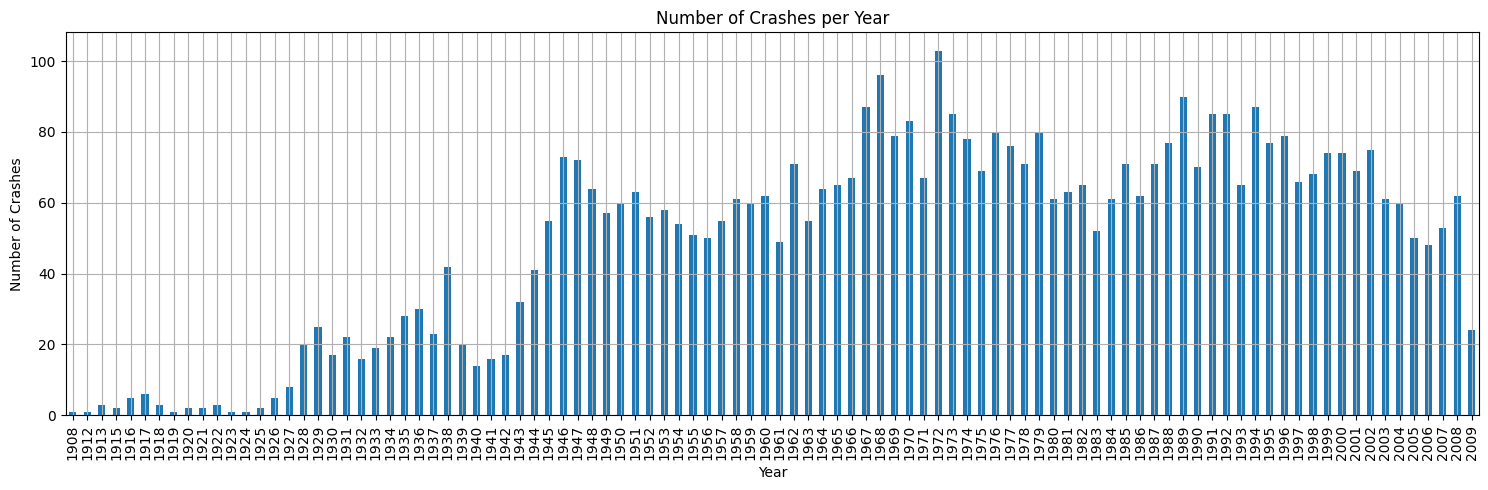

In [226]:
df_revised['Year'].value_counts().sort_index().plot(kind='bar', figsize=(15,5))
plt.title('Number of Crashes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.grid(True)
plt.tight_layout()
plt.show()

In [152]:
# here you can see clearly that n year1999 ,the number of crashesh is highst, also it is variate trends of number of crashesh  in each year

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\1493979693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df_revised, order=month_order, palette='viridis')


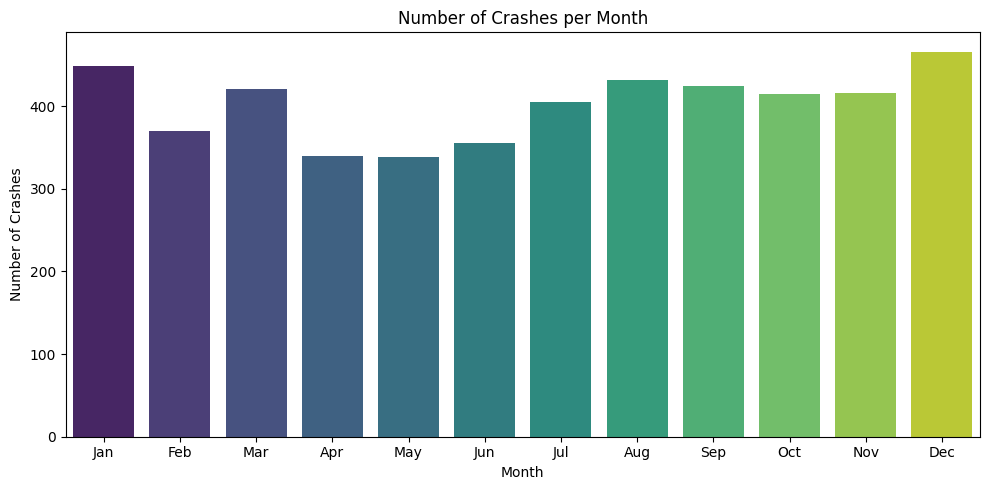

In [227]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=df_revised, order=month_order, palette='viridis')
plt.title('Number of Crashes per Month')
plt.xlabel('Month')
plt.ylabel('Number of Crashes')
plt.tight_layout()
plt.show()

In [154]:
# here you can see that in january the numbr of crashesh are the highest

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\3707962769.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ops.values, y=top_ops.index, palette='viridis')


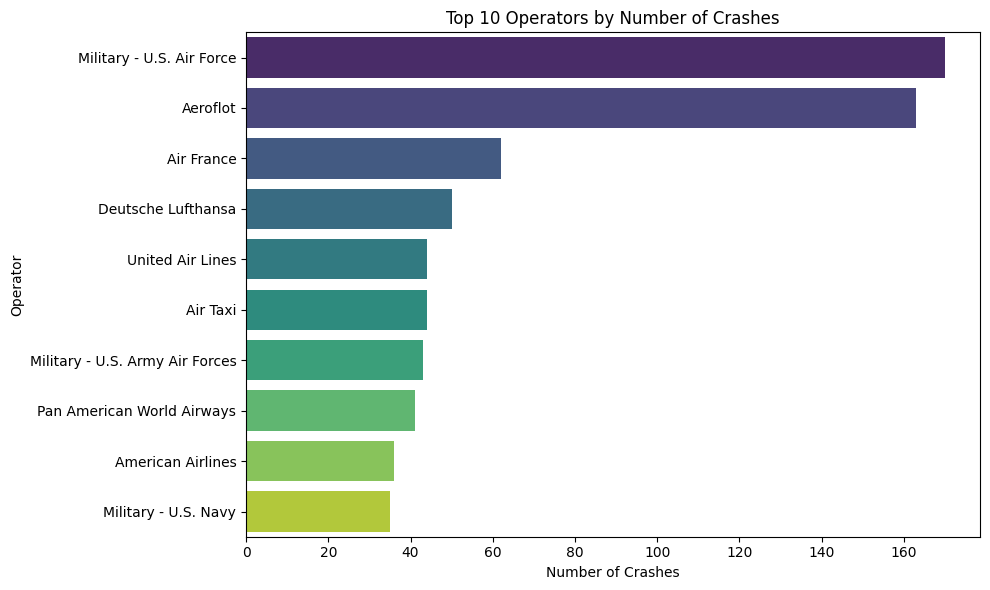

In [228]:
top_ops = df_revised['Operation_carried_by'].value_counts().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_ops.values, y=top_ops.index, palette='viridis')
plt.title('Top 10 Operators by Number of Crashes')
plt.xlabel('Number of Crashes')
plt.ylabel('Operator')
plt.tight_layout()
plt.show()



In [156]:
# military US air force operates in most number of crashesh

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\3697469810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


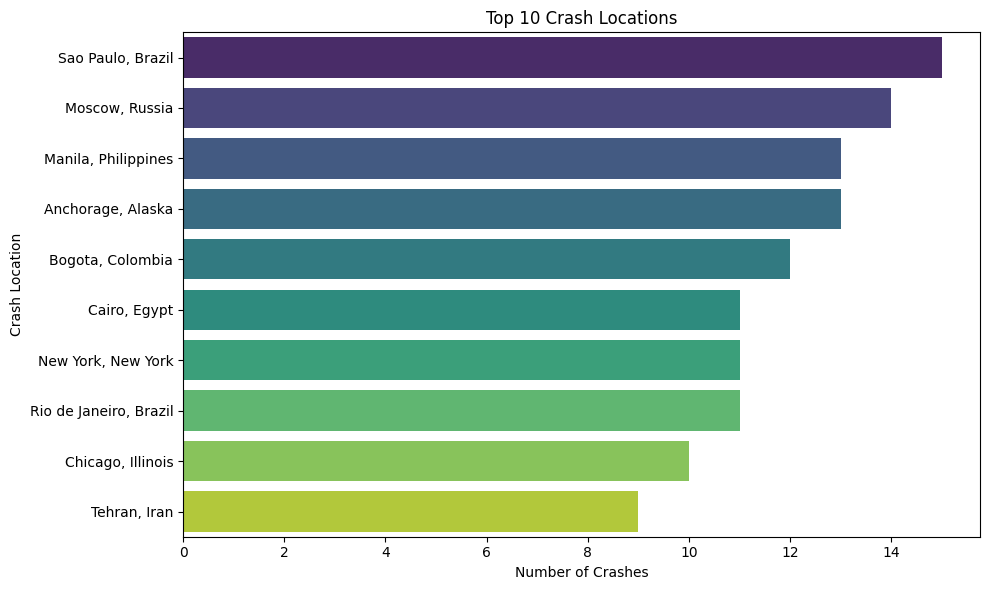

In [229]:
top_locations = df_revised['Crash_Location'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Crash Locations')
plt.xlabel('Number of Crashes')
plt.ylabel('Crash Location')
plt.tight_layout()
plt.show()

In [158]:
# sau paulo brazil had the highest number of crashesh

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\229385786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')


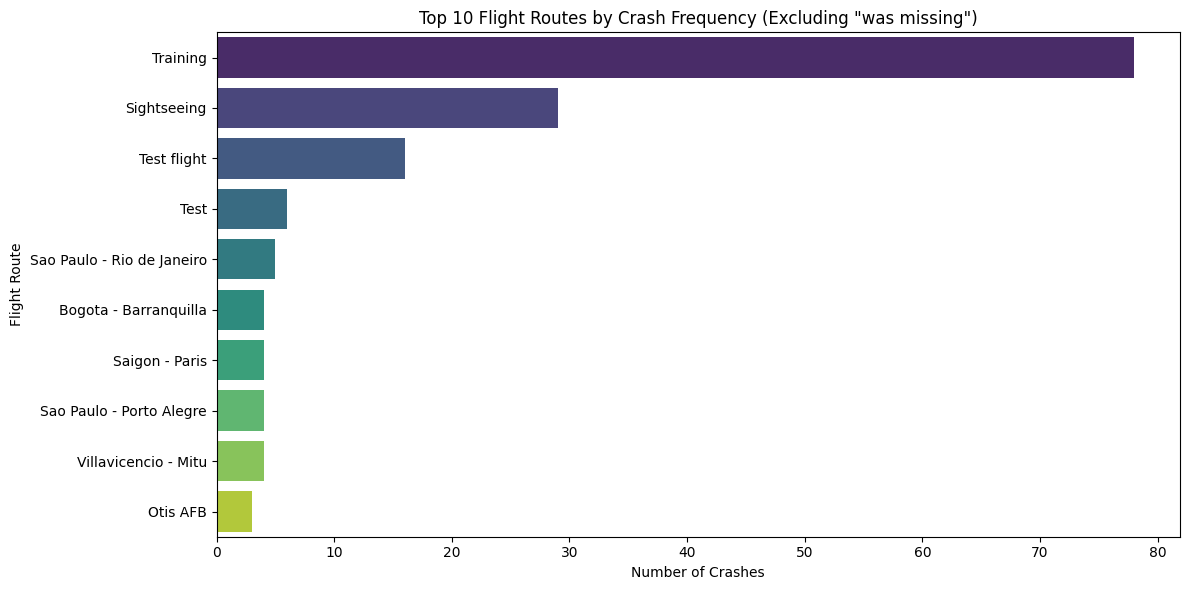

In [230]:
df_revised['Flight_Route'] = df_revised['Flight_Route'].str.strip()

filtered_routes = df_revised[
    (df_revised['Flight_Route'].notna()) &
    (df_revised['Flight_Route'].str.lower() != 'was missing')
]

# Top 10 routes by crash frequency
top_routes = filtered_routes['Flight_Route'].value_counts().nlargest(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')
plt.title('Top 10 Flight Routes by Crash Frequency (Excluding "was missing")')
plt.xlabel('Number of Crashes')
plt.ylabel('Flight Route')
plt.tight_layout()
plt.show()

In [160]:
# here "was missing" removed also it is quite visible training has the top 10 flight route

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\1869369820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')


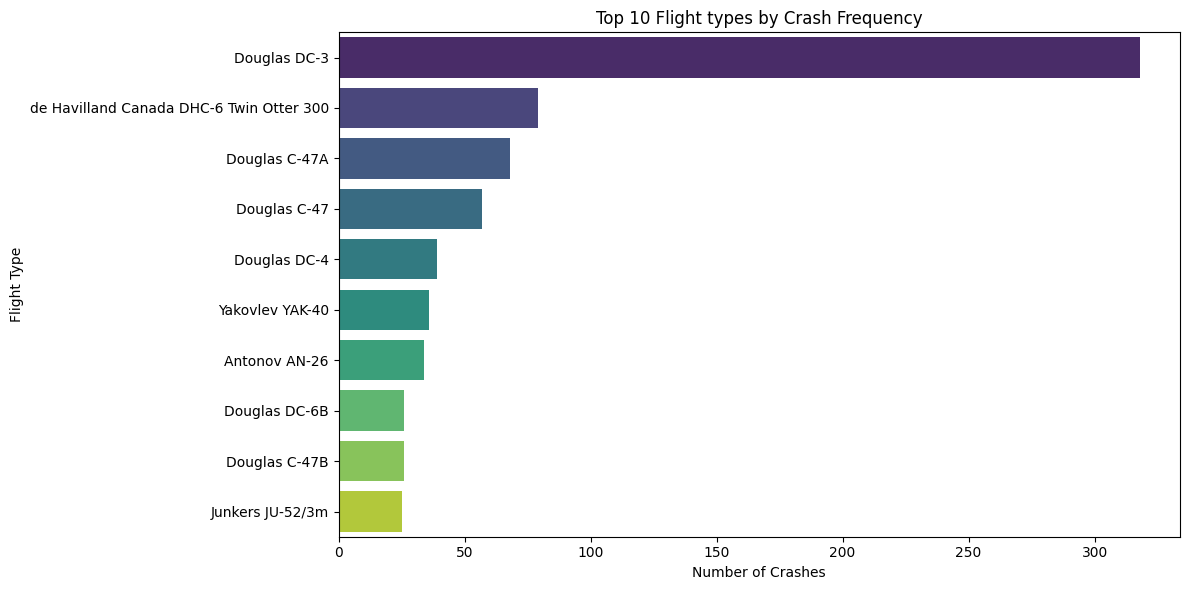

In [231]:
top_routes = df_revised['Flight_Type'].value_counts().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')
plt.title('Top 10 Flight types by Crash Frequency')
plt.xlabel('Number of Crashes')
plt.ylabel('Flight Type')
plt.tight_layout()
plt.show()

In [162]:
# douglas DC-3 flight type has highest number of crashesh 

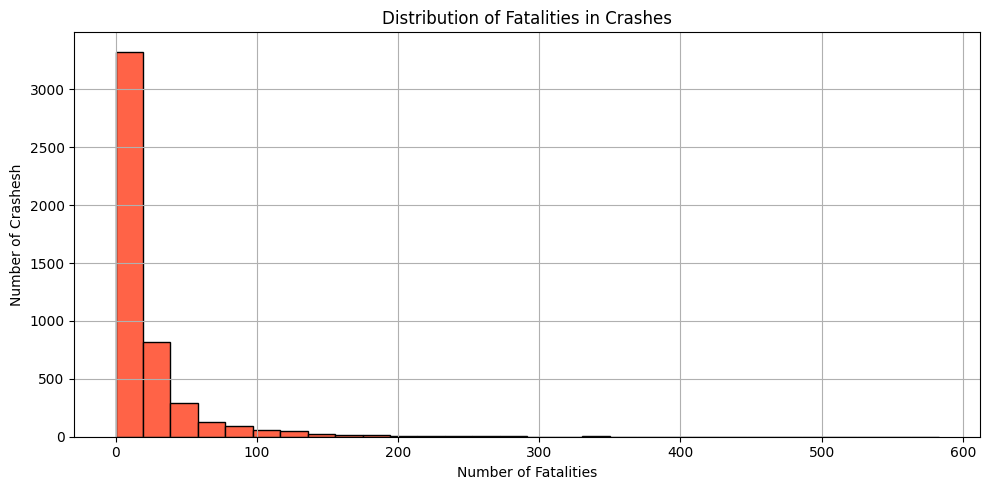

In [232]:
plt.figure(figsize=(10,5))
plt.hist(df_revised['Fatalities_in_Crash'].dropna(), bins=30, color='tomato', edgecolor='black')
plt.title('Distribution of Fatalities in Crashes')
plt.xlabel('Number of Fatalities')
plt.ylabel('Number of Crashesh')
plt.grid(True)
plt.tight_layout()
plt.show()

In [233]:
# fatalities by number of crashesh

In [ ]:
# Bivariate ANALYSIS

In [ ]:
# top_10_ops = df_revised['Operation_carried_by'].value_counts().nlargest(10).index
# data = df_revised[df_revised['Operation_carried_by'].isin(top_10_ops)]

# plt.figure(figsize=(16,7))
# sns.countplot(data=data, x='Year', hue='Operation_carried_by', palette='tab10')
# plt.title('Crashes per Year by Top 10 Operators')
# plt.xlabel('Year')
# plt.ylabel('Number of Crashes')
# plt.legend(title='Operator', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\3279902484.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fatal_by_group = df_revised.groupby('Year_Group')['Fatalities_in_Crash'].sum().reset_index()
C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\3279902484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fatal_by_group, x='Year_Group', y='Fatalities_in_Crash', palette='flare')


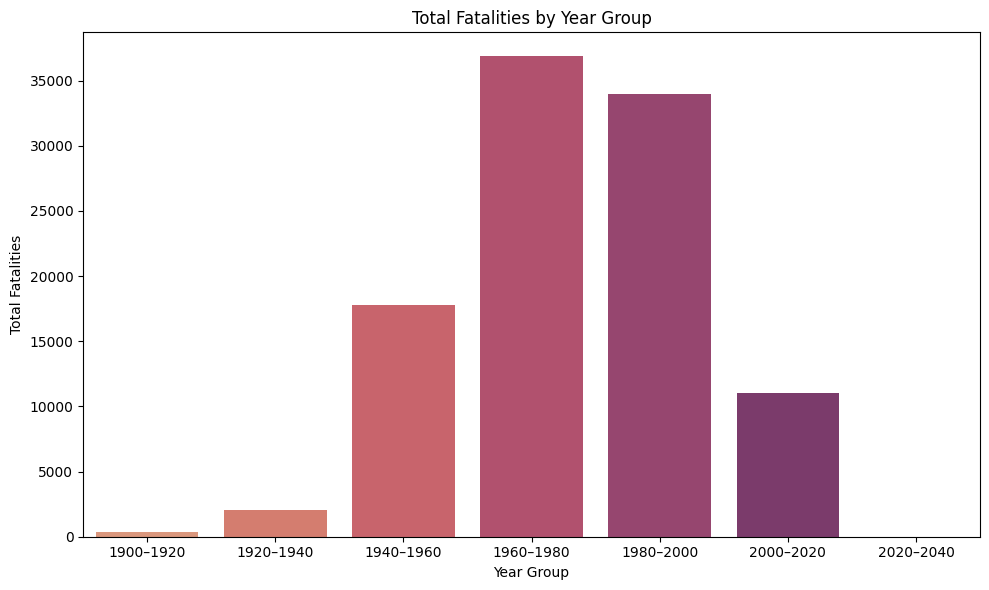

In [234]:
fatal_by_group = df_revised.groupby('Year_Group')['Fatalities_in_Crash'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=fatal_by_group, x='Year_Group', y='Fatalities_in_Crash', palette='flare')
plt.title('Total Fatalities by Year Group')
plt.xlabel('Year Group')
plt.ylabel('Total Fatalities')
plt.tight_layout()
plt.show()

In [ ]:
# here 1960-1980 age group have the highest number of ftaities 

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\2917557749.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fatal_by_month, x='Month', y='Fatalities_in_Crash', palette='crest')


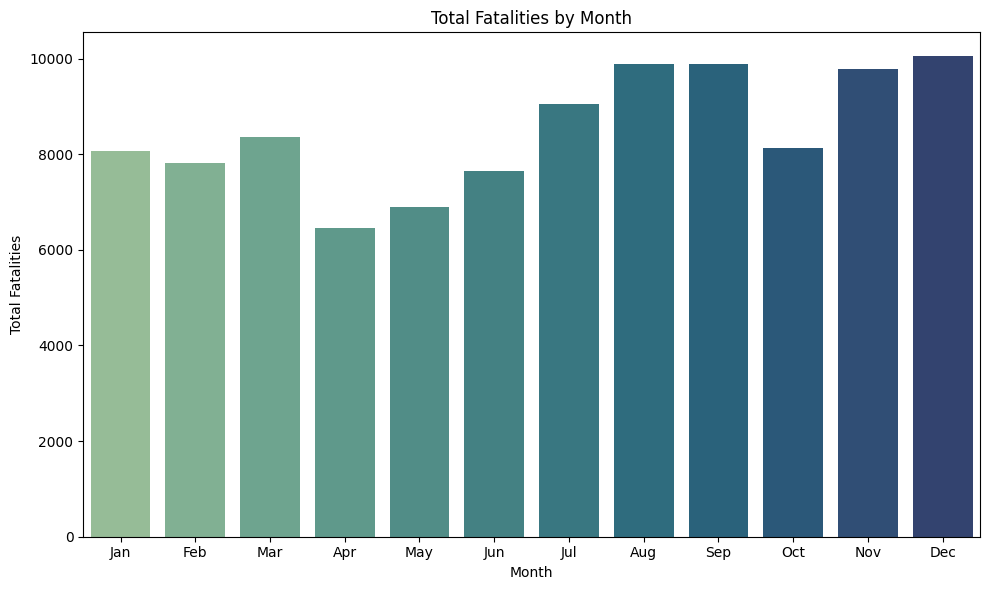

In [235]:
fatal_by_month = df_revised.groupby('Month')['Fatalities_in_Crash'].sum().reindex([
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=fatal_by_month, x='Month', y='Fatalities_in_Crash', palette='crest')
plt.title('Total Fatalities by Month')
plt.xlabel('Month')
plt.ylabel('Total Fatalities')
plt.tight_layout()
plt.show()

In [ ]:
# here monthly analysis based on number of fatalities is provided, and quite visisble that aug andd sept have the kind of same number of fatalities

In [236]:
df_revised.head()

,Crash_Date,Crash_Location,Operation_carried_by,Flight_Route,Flight_Type,Flight_Registration_Number,Fatalities_in_Crash,Crash_Description,Year,Month,Day,Year_Group
0,1908-09-17,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,Not Available,1.0,"During a demonstration flight, a U.S. Army fly...",1908,Sep,17,1900–1920
1,1912-07-12,"AtlantiCity, New Jersey",Military - U.S. Navy,Test flight,Dirigible,Not Available,5.0,First U.S. dirigible Akron exploded just offsh...,1912,Jul,12,1900–1920
2,1913-08-06,"Victoria, British Columbia, Canada",Private,Was Missing,Curtiss seaplane,Not Available,1.0,The first fatal airplane accident in Canada oc...,1913,Aug,6,1900–1920
3,1913-09-09,Over the North Sea,Military - German Navy,Was Missing,Zeppelin L-1 (airship),Not Available,14.0,The airship flew into a thunderstorm and encou...,1913,Sep,9,1900–1920
4,1913-10-17,"Near Johannisthal, Germany",Military - German Navy,Was Missing,Zeppelin L-2 (airship),Not Available,30.0,Hydrogen gas which was being vented was sucked...,1913,Oct,17,1900–1920


C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\4256659189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_locations, x='Fatalities_in_Crash', y='Crash_Location', palette='rocket')


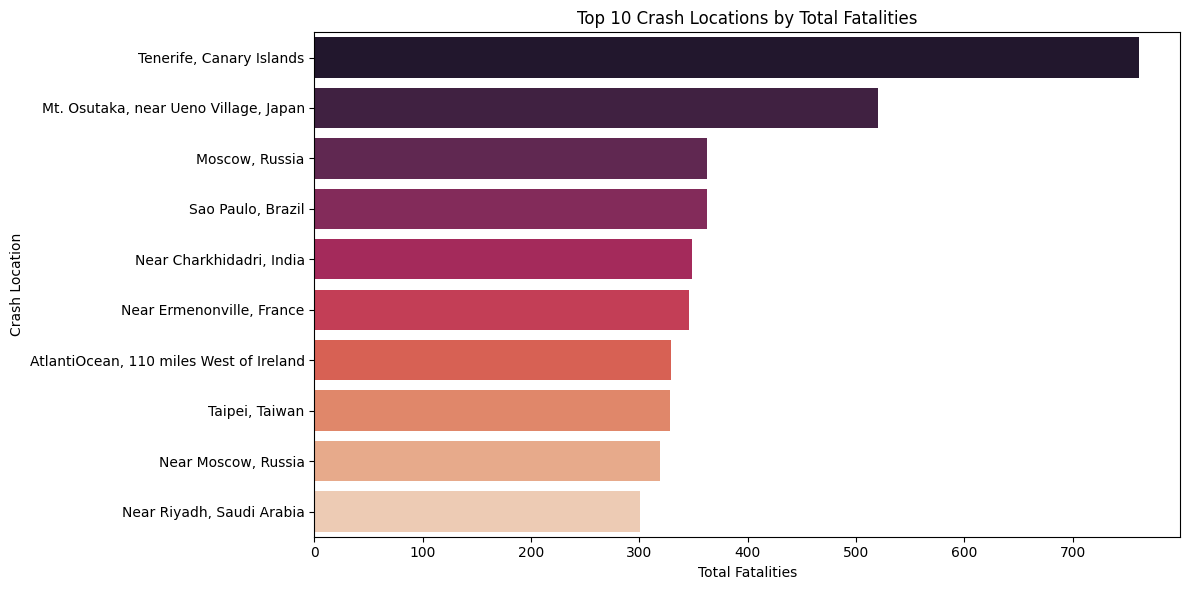

In [237]:
top_locations = df_revised.groupby('Crash_Location')['Fatalities_in_Crash'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_locations, x='Fatalities_in_Crash', y='Crash_Location', palette='rocket')
plt.title('Top 10 Crash Locations by Total Fatalities')
plt.xlabel('Total Fatalities')
plt.ylabel('Crash Location')
plt.tight_layout()
plt.show()

In [167]:
# here based on to 10 crash locaton like tenerif canary island has th highest number o total fatalities

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\2814179575.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_flight_types, x='Fatalities_in_Crash', y='Flight_Type', palette='flare')


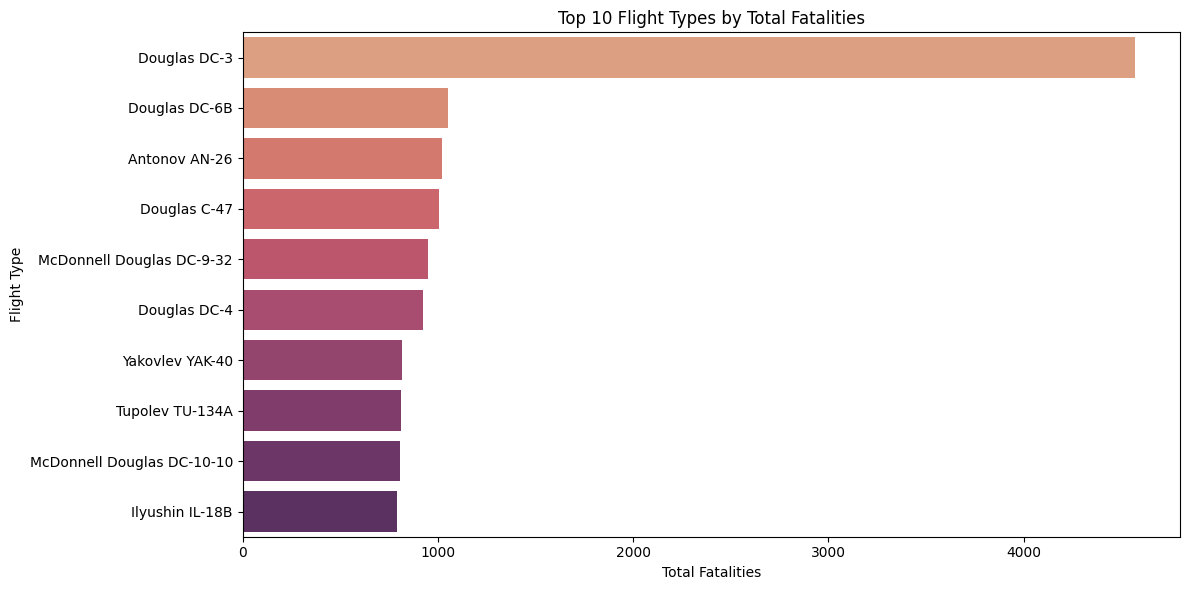

In [238]:
top_flight_types = df_revised.groupby('Flight_Type')['Fatalities_in_Crash'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_flight_types, x='Fatalities_in_Crash', y='Flight_Type', palette='flare')
plt.title('Top 10 Flight Types by Total Fatalities')
plt.xlabel('Total Fatalities')
plt.ylabel('Flight Type')
plt.tight_layout()
plt.show()

In [169]:
# here it is top 10 flight types b total fatalities and we can conclude that douglas dc 3 have the hihest fatalities

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\2996973647.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ops, x='Fatalities_in_Crash', y='Operation_carried_by', palette='magma')


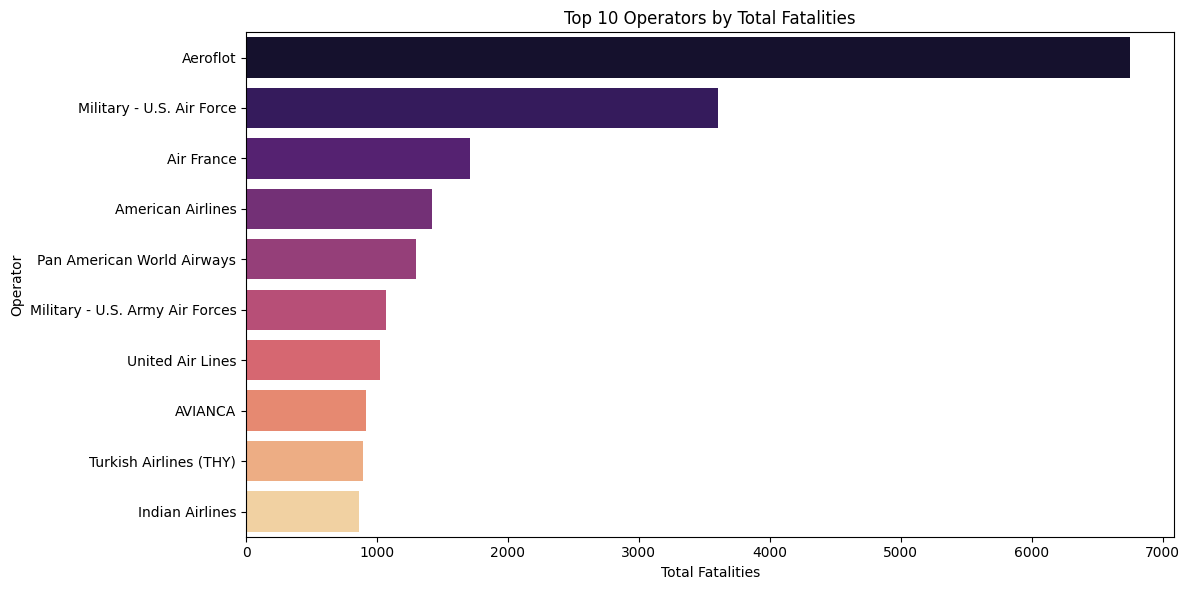

In [239]:
top_ops = df_revised.groupby('Operation_carried_by')['Fatalities_in_Crash'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_ops, x='Fatalities_in_Crash', y='Operation_carried_by', palette='magma')
plt.title('Top 10 Operators by Total Fatalities')
plt.xlabel('Total Fatalities')
plt.ylabel('Operator')
plt.tight_layout()
plt.show()

In [171]:
# here we conclude that opration carried by different associations with number of fatalities

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\612747585.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_routes, x='Fatalities_in_Crash', y='Flight_Route', palette='inferno')


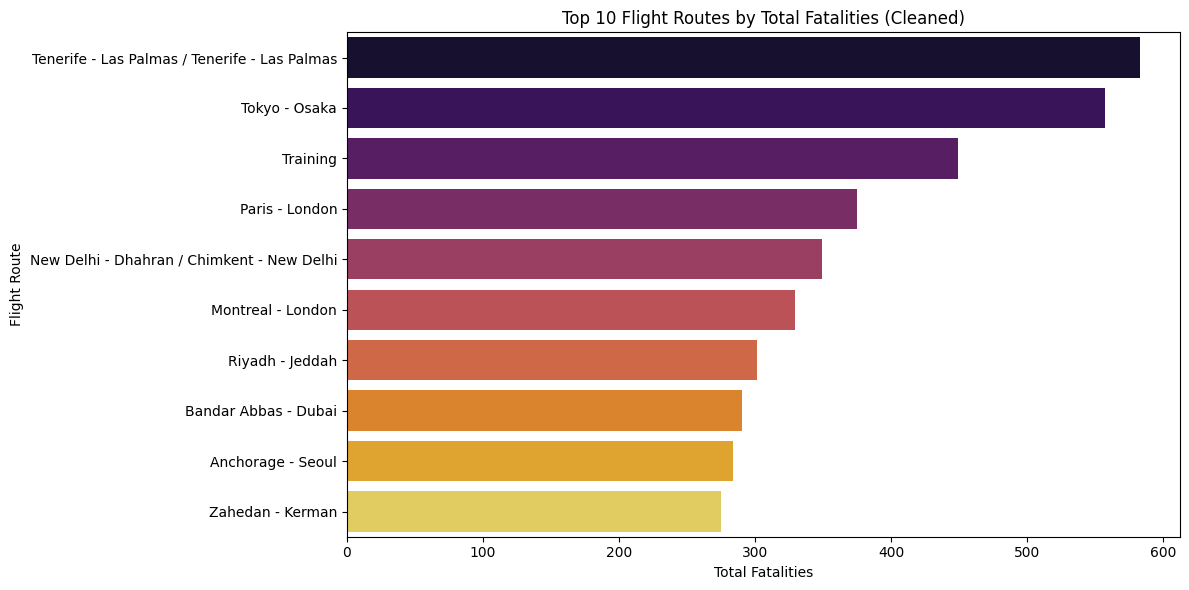

In [240]:
df_revised['Flight_Route'] = df_revised['Flight_Route'].str.strip()

# Filter out 'was missing' and NaN
filtered_df = df_revised[
    (df_revised['Flight_Route'].notna()) &
    (df_revised['Flight_Route'].str.lower() != 'was missing')
]

# Get top 10 routes by fatalities
top_routes = filtered_df.groupby('Flight_Route')['Fatalities_in_Crash'].sum().nlargest(10).reset_index()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=top_routes, x='Fatalities_in_Crash', y='Flight_Route', palette='inferno')
plt.title('Top 10 Flight Routes by Total Fatalities (Cleaned)')
plt.xlabel('Total Fatalities')
plt.ylabel('Flight Route')
plt.tight_layout()
plt.show()


# isme se was missing hatadiya ab dekho but wait krr chtgpt se help li h.....also   tenerif have the highest number of fatalities highest

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_6112\3079201160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_types, x='Fatalities_in_Crash', y='Flight_Type', palette='coolwarm')


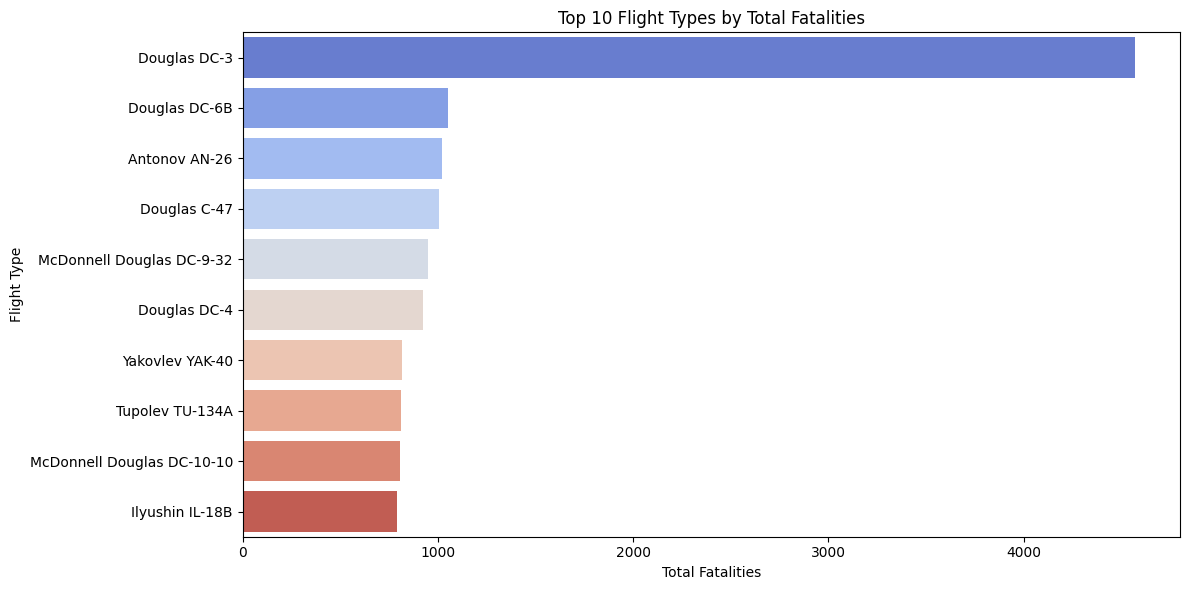

In [241]:
top_types = df_revised.groupby('Flight_Type')['Fatalities_in_Crash'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_types, x='Fatalities_in_Crash', y='Flight_Type', palette='coolwarm')
plt.title('Top 10 Flight Types by Total Fatalities')
plt.xlabel('Total Fatalities')
plt.ylabel('Flight Type')
plt.tight_layout()
plt.show()
# top 10 flight type by total number of fatalities

In [242]:
# top_locations = df_revised['Crash_Location'].value_counts().nlargest(10).index

# # Filter data
# filtered = df_revised[df_revised['Crash_Location'].isin(top_locations)]

# # Group and count
# grouped = filtered.groupby(['Crash_Location', 'Operation_carried_by']).size().reset_index(name='Crash_Count')

# # Plot
# plt.figure(figsize=(14,6))
# sns.barplot(data=grouped, x='Crash_Count', y='Crash_Location', hue='Operation_carried_by', dodge=True, palette='Spectral')
# plt.title('Crashes by Operator Type across Top Crash Locations')
# plt.xlabel('Number of Crashes')
# plt.ylabel('Crash Location')
# plt.tight_layout()
# plt.legend(title='Operator Type')
# plt.show()

In [243]:
df.to_csv('air_crashes_cleaned.csv', index=False)